In [24]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
df1=pd.read_csv("E:\project1\customer_churn_data.csv")

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\User\AppData\Local\Temp\ipykernel_36476\2621463143.py:1: SyntaxWarning: invalid escape sequence '\p'
  df1=pd.read_csv("E:\project1\customer_churn_data.csv")


In [27]:
df1.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [28]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   str    
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   str    
 6   InternetService  703 non-null    str    
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   str    
 9   Churn            1000 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 78.3 KB


In [29]:
df1.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [30]:
df1.shape


(1000, 10)

# Data Cleaning

In [31]:
df=df1.drop(['CustomerID'],axis=1)


In [32]:
df


,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes
...,...,...,...,...,...,...,...,...,...
995,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,62,Male,9,80.93,Month-to-Month,NaN,728.37,No,Yes
997,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,39,Male,68,65.67,One-Year,NaN,4465.56,No,Yes


In [33]:
df.isnull().sum()

Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [34]:
df["InternetService"] = df["InternetService"].fillna(df["InternetService"].mode()[0])

In [35]:
df.isnull().sum()

Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
numeric_cols=df.select_dtypes(include=['number'])
numeric_cols

,Age,Tenure,MonthlyCharges,TotalCharges
0,49,4,88.35,353.40
1,43,0,36.67,0.00
2,51,2,63.79,127.58
3,60,8,102.34,818.72
4,42,32,69.01,2208.32
...,...,...,...,...
995,42,41,37.14,1522.74
996,62,9,80.93,728.37
997,51,15,111.72,1675.80
998,39,68,65.67,4465.56


In [38]:
numeric_cols.corr()

,Age,Tenure,MonthlyCharges,TotalCharges
Age,1.000000,0.000472,0.006362,-0.001896
Tenure,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.001896,0.894868,0.304893,1.000000


# **Data Visualization**


In [39]:
df['Churn'].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

<Axes: >

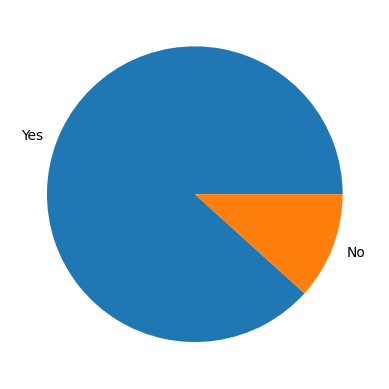

In [40]:
df['Churn'].value_counts().plot(kind='pie')

In [41]:
df.groupby("Churn")['Age'].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

In [42]:
df.groupby(["Churn","Gender"])['Age'].mean()


Churn  Gender
No     Female    43.838235
       Male      43.000000
Yes    Female    45.287234
       Male      44.312349
Name: Age, dtype: float64

Text(0.5, 1.0, 'churn based on gender')

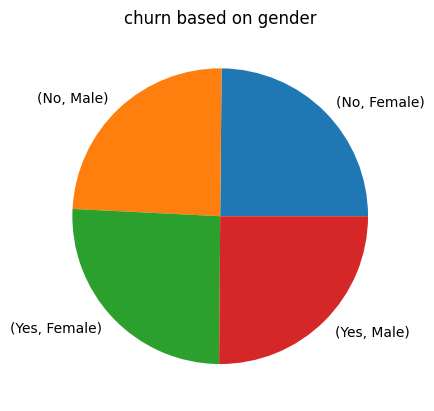

In [43]:
df.groupby(["Churn","Gender"])['Age'].mean().plot(kind="pie")
plt.title("churn based on gender")

In [44]:
df.groupby("ContractType")["MonthlyCharges"].mean()

ContractType
Month-to-Month    75.909198
One-Year          73.822803
Two-Year          71.334500
Name: MonthlyCharges, dtype: float64

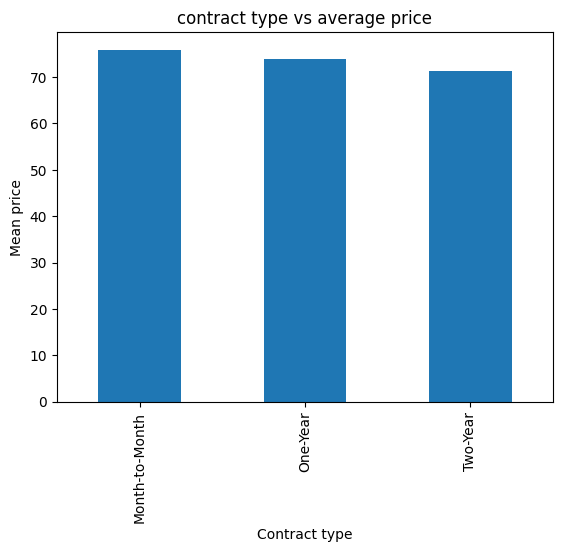

In [45]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind='bar')
plt.title('contract type vs average price')
plt.xlabel("Contract type")
plt.ylabel("Mean price")
plt.show()

In [46]:
df.head()

,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,42,Male,32,69.01,Month-to-Month,Fiber Optic,2208.32,No,Yes


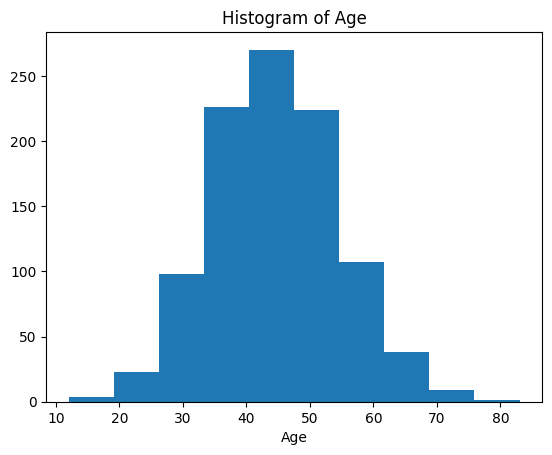

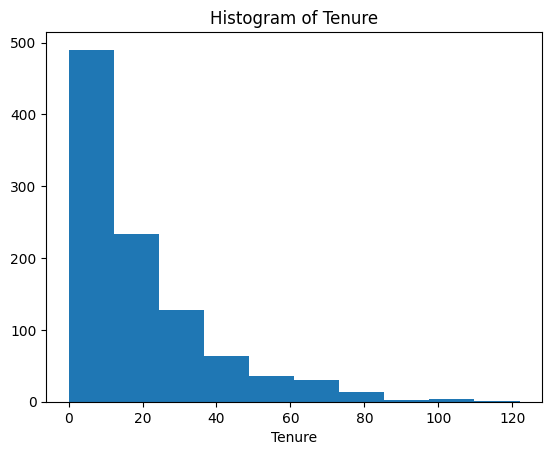

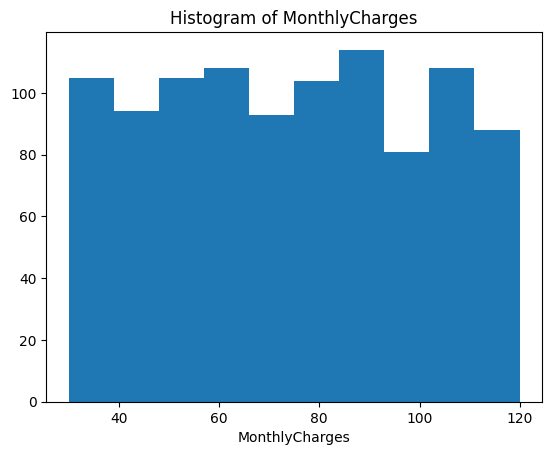

In [47]:
cols=['Age','Tenure','MonthlyCharges']
for col in cols:
    plt.hist(df[col])
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.show()

In [48]:
# Tenure is right-skewed.
#Most customers leave early, and only a small number stay for a very long time.

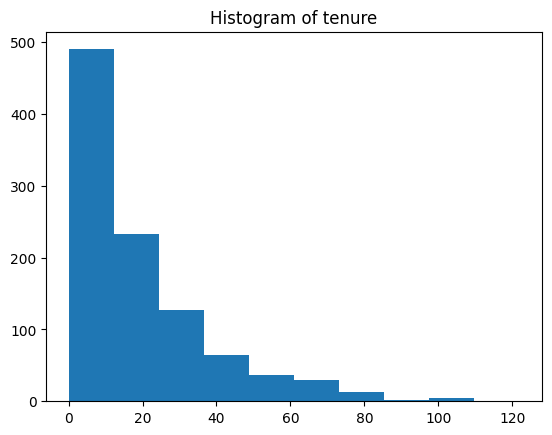

In [49]:
cols=['']
plt.hist(df["Tenure"])
plt.title("Histogram of tenure")
plt.show()

# Feature Engineering

In [50]:
df.head()

,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,42,Male,32,69.01,Month-to-Month,Fiber Optic,2208.32,No,Yes


In [51]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'MonthlyCharges', 'ContractType',
       'InternetService', 'TotalCharges', 'TechSupport', 'Churn'],
      dtype='str')

In [52]:
df["ContractType"].value_counts()

ContractType
Month-to-Month    511
One-Year          289
Two-Year          200
Name: count, dtype: int64

In [53]:
df["InternetService"].value_counts()

InternetService
Fiber Optic    692
DSL            308
Name: count, dtype: int64

In [54]:
df["TechSupport"].value_counts()

TechSupport
Yes    506
No     494
Name: count, dtype: int64

In [55]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])     
y = df['Churn']

y = y.map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

transformer = ColumnTransformer(
    transformers=[
        ('ohe',OneHotEncoder(drop='first', handle_unknown='ignore'),
         ['ContractType', 'InternetService', 'TechSupport','Gender'])
    ],remainder='passthrough'
)

X_train_tf = transformer.fit_transform(X_train)
X_test_tf  = transformer.transform(X_test)


In [57]:
transformer.fit(X_train)

feature_names = transformer.get_feature_names_out()
print(feature_names)


['ohe__ContractType_One-Year' 'ohe__ContractType_Two-Year'
 'ohe__InternetService_Fiber Optic' 'ohe__TechSupport_Yes'
 'ohe__Gender_Male' 'remainder__Age' 'remainder__Tenure'
 'remainder__MonthlyCharges' 'remainder__TotalCharges']


In [58]:
X_train_tf = transformer.fit_transform(X_train)

X_train_tf_df = pd.DataFrame(
    X_train_tf,
    columns=transformer.get_feature_names_out(),
    index=X_train.index
)

X_train_tf_df.head()


,ohe__ContractType_One-Year,ohe__ContractType_Two-Year,ohe__InternetService_Fiber Optic,ohe__TechSupport_Yes,ohe__Gender_Male,remainder__Age,remainder__Tenure,remainder__MonthlyCharges,remainder__TotalCharges
270,0.0,0.0,1.0,1.0,0.0,59.0,5.0,81.69,408.45
938,1.0,0.0,1.0,1.0,0.0,47.0,9.0,31.88,286.92
329,1.0,0.0,1.0,0.0,0.0,51.0,66.0,53.69,3543.54
886,0.0,0.0,0.0,0.0,1.0,50.0,7.0,91.40,639.80
769,0.0,0.0,1.0,0.0,0.0,63.0,6.0,39.26,235.56


In [59]:
y_train.head()

270    1
938    1
329    1
886    1
769    1
Name: Churn, dtype: int64

In [60]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train_tf, y_train)
pred = gb.predict(X_test_tf)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


[[ 23   0]
 [  0 177]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       177

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [61]:
gb.score(X_train_tf,y_train)


1.0

In [62]:
gb.score(X_test_tf,y_test)

1.0

In [63]:
#overfitting due to the small dataset

In [64]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

lr  = LogisticRegression(max_iter=1000)
rf  = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
svm = SVC(probability=True)

vote = VotingClassifier(
    estimators=[("lr", lr), ("rf", rf), ("svm", svm)],
    voting="soft"
)

vote.fit(X_train_tf, y_train)
pred = vote.predict(X_test_tf)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


e:\project1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[[ 12  11]
 [  0 177]]
              precision    recall  f1-score   support

           0       1.00      0.52      0.69        23
           1       0.94      1.00      0.97       177

    accuracy                           0.94       200
   macro avg       0.97      0.76      0.83       200
weighted avg       0.95      0.94      0.94       200



In [65]:
#The voting classifier achieves 95% accuracy, but it performs weaker on class 0 with recall 0.57, meaning it misses 10 out of 23 class-0 cases. The model performs extremely well on class 1 (recall 1.00). For deployment, we should focus on improving class-0 recall using class weights, SMOTE, or by adjusting the prediction threshold.

In [66]:
print(y_train.value_counts())
print(y_test.value_counts())
print(X.shape)
print(X_train.shape, X_test.shape)


Churn
1    706
0     94
Name: count, dtype: int64
Churn
1    177
0     23
Name: count, dtype: int64
(1000, 8)
(800, 8) (200, 8)


In [67]:
import pandas as pd

# Works if X_train and X_test are DataFrames
dup = pd.merge(X_train.reset_index(drop=True), X_test.reset_index(drop=True), how='inner')
print("Exact duplicate rows between train & test:", dup.shape[0])


Exact duplicate rows between train & test: 0


In [68]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 1) Fit transformer (or use the already-fit one)
X_train_tf = transformer.fit_transform(X_train)
X_test_tf  = transformer.transform(X_test)

# 2) Fit RandomForest
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf.fit(X_train_tf, y_train)

# 3) Now you can get feature importances
feat_names = transformer.get_feature_names_out()
imps = rf.feature_importances_

top = np.argsort(imps)[::-1][:15]
for i in top:
    print(feat_names[i], imps[i])



ohe__TechSupport_Yes 0.29710167054105496
remainder__Tenure 0.23044281781034687
remainder__MonthlyCharges 0.1204528073178281
ohe__ContractType_One-Year 0.11599587058220341
ohe__ContractType_Two-Year 0.11023409079459327
remainder__TotalCharges 0.10710280743106548
remainder__Age 0.014128490533825767
ohe__InternetService_Fiber Optic 0.002791200069108505
ohe__Gender_Male 0.001750244919973614


In [69]:
print("Train:", rf.score(X_train_tf, y_train))
print("Test :", rf.score(X_test_tf, y_test))



Train: 1.0
Test : 1.0


In [70]:


y_shuf = y_train.sample(frac=1, random_state=42).values

rf_shuf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf_shuf.fit(X_train_tf, y_shuf)

print("Shuffled-label test score:", rf_shuf.score(X_test_tf, y_test))


Shuffled-label test score: 0.885


In [71]:
#The shuffled-label test drops to the baseline accuracy (0.885), which indicates the model’s perfect score is not due to leakage. The model is likely separating churn well using strong predictors like TechSupport, Tenure, and ContractType.

In [72]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

cat_cols = ['ContractType','InternetService','TechSupport','Gender']
preprocess = ColumnTransformer(
    [('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)],
    remainder='passthrough'
)

pipe = Pipeline([
    ('prep', preprocess),
    ('rf', RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
print(scores, "mean:", scores.mean())


[1.   1.   1.   0.99 1.  ] mean: 0.998


In [73]:
#Cross-validation results show consistently high accuracy (~99.8%), indicating that the model generalizes well across different data splits. A shuffled-label test drops accuracy to the baseline level, confirming that the model’s performance is not due to data leakage but to strong predictive features such as tenure, contract type, and technical support.

In [74]:
from sklearn.metrics import roc_auc_score, classification_report

proba = rf.predict_proba(X_test_tf)[:,1]
print("AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, rf.predict(X_test_tf)))


AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       177

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



# Caution!! In real-world deployment, performance may decrease due to data drift and unseen patterns, so monitoring is required.

In [75]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("prep", transformer),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"))
])

pipe.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matr

In [76]:
import joblib
joblib.dump(pipe, "churn_rf_pipeline.pkl")



['churn_rf_pipeline.pkl']

In [77]:
import sys
print(sys.executable)
print(sys.version)


e:\project1\.venv\Scripts\python.exe
3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]


In [78]:
%pip install -U pip
%pip install numpy pandas matplotlib scikit-learn joblib imbalanced-learn



Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [79]:
%pip install numpy pandas matplotlib scikit-learn joblib imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [80]:
import sklearn, joblib
import pandas as pd
import matplotlib.pyplot as plt
print("sklearn:", sklearn.__version__)
print("joblib ok")


sklearn: 1.8.0
joblib ok


In [82]:
import joblib
pipe = joblib.load("churn_rf_pipeline.pkl")
